# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [2]:
# Load the VIX dataset
df = pd.read_csv("vix.csv")
print(df.head())

# Extract features and target
x = df["year"].values
y = df["vix"].values

# Step 1: Split into 80% train+val and 20% test
x_trainval, x_test, y_trainval, y_test = train_test_split(x, y, test_size=0.2, random_state=35)
x_train, x_val, y_train, y_val = train_test_split(x_trainval, y_trainval, test_size=0.25, random_state=35)

# Shape
print("Train size:", len(x_train))
print("Validation size:", len(x_val))
print("Test size:", len(x_test))


     vix  year
0  17.24  1990
1  18.19  1990
2  19.22  1990
3  20.11  1990
4  20.26  1990
Train size: 5352
Validation size: 1784
Test size: 1784


In [3]:
# Piecewise Constant Design Matrix Function
def design_mat_pwc(x, k):
    x_min = np.min(x)
    x_max = np.max(x)
    n = len(x)
    phi_mat = np.ones((n, 1))

    for i in range(1, k + 1):
        t = x_min + i * (x_max - x_min) / (k + 1)
        phi_i = (x > t).astype(int)
        phi_mat = np.hstack((phi_mat, phi_i.reshape(-1, 1)))

    return phi_mat

In [4]:
# Piecewise Linear Function
def design_mat_pwl(x, k):
    x = np.asarray(x)
    x_min = np.min(x)
    x_max = np.max(x)
    n = len(x)
    phi_mat = np.ones((n, 1))  # constant term
    phi_mat = np.hstack((phi_mat, x.reshape(-1, 1)))
    for i in range(1, k + 1):
        t_i = x_min + i * (x_max - x_min) / (k + 1)
        lambda_i = (x - t_i) * (x > t_i)
        phi_mat = np.hstack((phi_mat, lambda_i.reshape(-1, 1)))
    return phi_mat

In [5]:
# Radial Basis Function
def design_mat_rbf(x, k):
    x = np.asarray(x)
    x_min = np.min(x)
    x_max = np.max(x)
    n = len(x)
    phi_mat = np.ones((n, 1))

    for i in range(1, k + 1):
        t = x_min + i * (x_max - x_min) / (k + 1)
        phi_i = np.exp(-((x - t) ** 2) / 8)
        phi_mat = np.hstack((phi_mat, phi_i.reshape(-1, 1)))
    return phi_mat

In [6]:
# Laplace Basis Function
def design_mat_laplace(x, k):
    x = np.asarray(x)
    x_min = np.min(x)
    x_max = np.max(x)
    n = len(x)
    phi_mat = np.ones((n, 1))

    for i in range(1, k + 1):
        t = x_min + i * (x_max - x_min) / (k + 1)
        phi_i = np.exp(-np.abs(x - t) / 8)
        phi_mat = np.hstack((phi_mat, phi_i.reshape(-1, 1)))
    return phi_mat

In [7]:
# Function to tune k for any basis function
def tune_k(basis_func, x_train, y_train, x_val, y_val, k_values):
    best_k = None
    lowest_mse = float("inf")
    mse_list = []
    for k in k_values:
        Phi_train = basis_func(x_train, k)
        Phi_val = basis_func(x_val, k)
        model = LinearRegression()
        model.fit(Phi_train, y_train)
        y_pred = model.predict(Phi_val)
        mse = mean_squared_error(y_val, y_pred)
        mse_list.append(mse)
        if mse < lowest_mse:
            lowest_mse = mse
            best_k = k
    return best_k, mse_list

In [8]:
# Function to Predict
def evaluate_on_test(basis_func, x_trainval, y_trainval, x_test, y_test, k):
    Phi_trainval = basis_func(x_trainval, k)
    Phi_test = basis_func(x_test, k)
    model = LinearRegression()
    model.fit(Phi_trainval, y_trainval)
    y_pred = model.predict(Phi_test)
    test_mse = mean_squared_error(y_test, y_pred)
    return y_pred, test_mse

In [9]:
# Function to Predict New
def np_predict_new(phi_train, y_train, phi_predict):
    beta_hat = np.linalg.inv(phi_train.T @ phi_train) @ phi_train.T @ y_train
    y_hat = phi_predict @ beta_hat
    return y_hat

In [10]:
# Function to Plot
def plot_predictions(x_test, y_test, y_pred, model_name, k):
    plt.figure(figsize=(10, 5))
    plt.scatter(x_test, y_test, color='grey', s=5, alpha=0.1)
    plt.plot(x_test, y_pred, 'r.', markersize=6.0)
    plt.xlabel("Year")
    plt.ylabel("VIX")
    plt.title(f"{model_name} (k={k})")
    plt.tight_layout()
    plt.show()


In [11]:
# Test K from 0-30
k_range = range(1, 31)

# Tune using piecewise constant basis
best_k_pwc, mse_list_pwc = tune_k(design_mat_pwc, x_train, y_train, x_val, y_val, k_range)

# Tune using piecewise linear basis
best_k_pwl, mse_list_pwl = tune_k(design_mat_pwl, x_train, y_train, x_val, y_val, k_range)

# Tune using radial basis function
best_k_rbf, mse_list_rbf = tune_k(design_mat_rbf, x_train, y_train, x_val, y_val, k_range)

# Tune using laplace basis function
best_k_laplace, mse_list_laplace = tune_k(design_mat_laplace, x_train, y_train, x_val, y_val, k_range)

print("Best k for Piecewise Constant Basis:", best_k_pwc)
print("Best k for Piecewise Linear Basis:", best_k_pwl)
print("Best k for Radial Basis Function:", best_k_rbf)
print("Best k for Laplace Basis Function:", best_k_laplace)

Best k for Piecewise Constant Basis: 29
Best k for Piecewise Linear Basis: 22
Best k for Radial Basis Function: 27
Best k for Laplace Basis Function: 22


In [12]:
# Combine Training and Validation Data
x_trainval = np.concatenate([x_train, x_val])
y_trainval = np.concatenate([y_train, y_val])

In [13]:
# Evaluate on test set using best k from validation
y_pred_pwc, test_mse_pwc = evaluate_on_test(design_mat_pwc, x_trainval, y_trainval, x_test, y_test, best_k_pwc)
y_pred_pwl, test_mse_pwl = evaluate_on_test(design_mat_pwl, x_trainval, y_trainval, x_test, y_test, best_k_pwl)
y_pred_rbf, test_mse_rbf = evaluate_on_test(design_mat_rbf, x_trainval, y_trainval, x_test, y_test, best_k_rbf)
y_pred_laplace, test_mse_laplace = evaluate_on_test(design_mat_laplace, x_trainval, y_trainval, x_test, y_test, best_k_laplace)

# Print results
print("Test MSE (Piecewise Constant):", test_mse_pwc)
print("Test MSE (Piecewise Linear):", test_mse_pwl)
print("Test MSE (Radial Basis):", test_mse_rbf)
print("Test MSE (Laplace Basis):", test_mse_laplace)


Test MSE (Piecewise Constant): 31.785722325797344
Test MSE (Piecewise Linear): 31.36677562574196
Test MSE (Radial Basis): 31.552958066403797
Test MSE (Laplace Basis): 31.37056224461724


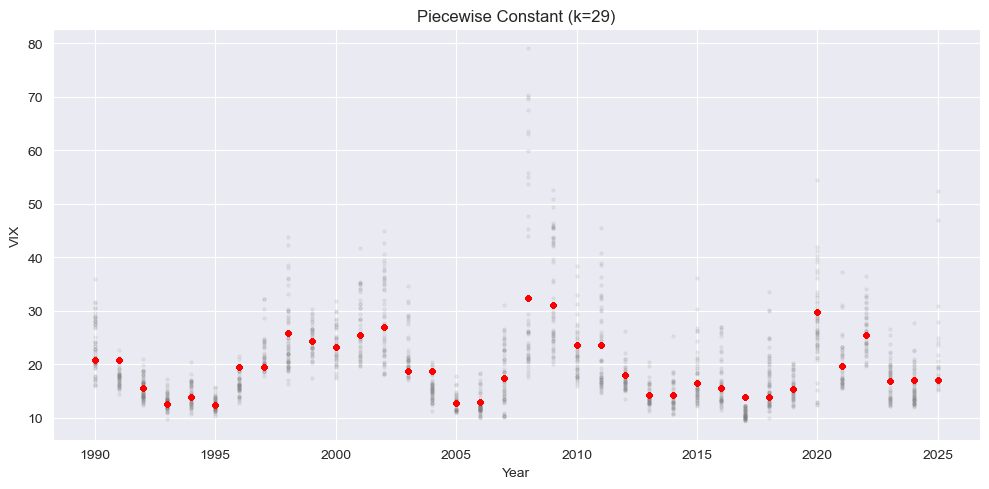

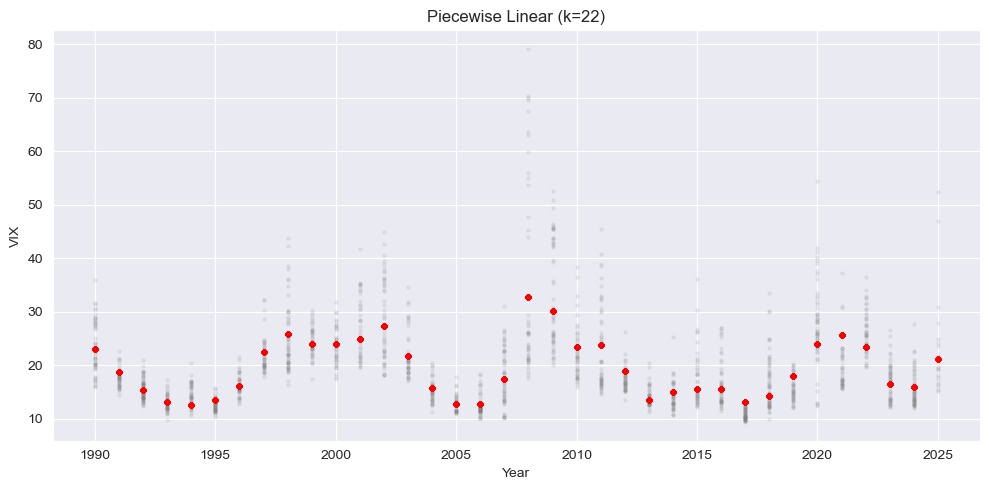

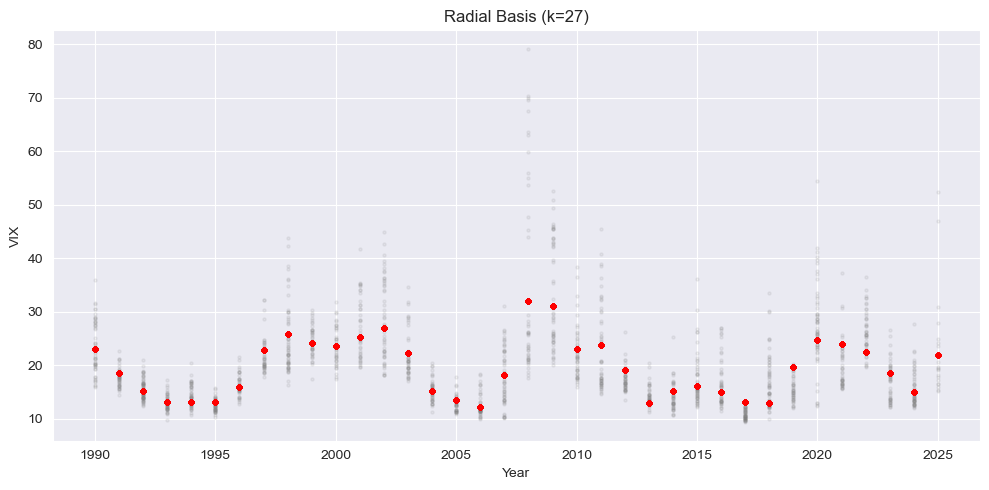

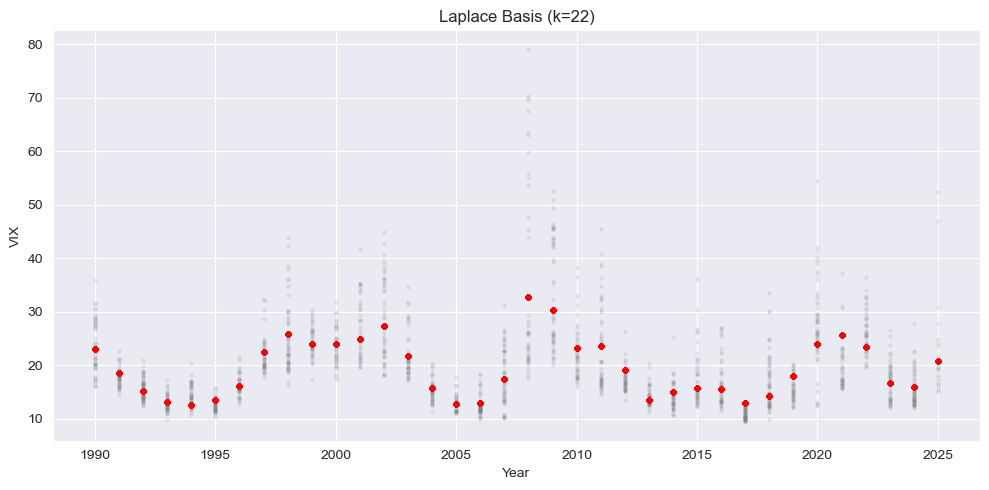

In [14]:
# Plot Piecewise Constant
plot_predictions(x_test, y_test, y_pred_pwc, "Piecewise Constant", best_k_pwc)

# Plot Piecewise Linear
plot_predictions(x_test, y_test, y_pred_pwl, "Piecewise Linear", best_k_pwl)

# Plot Radial Basis
plot_predictions(x_test, y_test, y_pred_rbf, "Radial Basis", best_k_rbf)

# Plot Laplace Basis
plot_predictions(x_test, y_test, y_pred_laplace, "Laplace Basis", best_k_laplace)

In [15]:
# Piecewise Linear is chosen as the best fitting method, with an MSE of 31.367 and k = 22

# Append the predicted X
x_new = np.append(x,[2026,2027,2028])

# Predict the data
PWL_new = design_mat_pwl(x_new,best_k_pwl)
phix_PWL = design_mat_pwl(x,best_k_pwl)

y_pred_new = np_predict_new(phix_PWL,y,PWL_new)

print("Forecasted VIX values for 2026–2028 (Piecewise Linear, k =", best_k_pwl, "):")
print("2026:", round(y_pred_new[-3], 2))
print("2027:", round(y_pred_new[-2], 2))
print("2028:", round(y_pred_new[-1], 2))

Forecasted VIX values for 2026–2028 (Piecewise Linear, k = 22 ):
2026: 14.74
2027: 15.87
2028: 21.36
